## Análise Exploratória de Dados — E-commerce

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import sqlite3

# CFG de visualização
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Carregando os dados

In [6]:
conn = sqlite3.connect("../data/database.db")

clientes = pd.read_sql("SELECT * FROM clientes", conn)
produtos = pd.read_sql("SELECT * FROM produtos", conn)
pedidos = pd.read_sql("SELECT * FROM pedidos", conn)
itens = pd.read_sql("SELECT * FROM itens_pedido", conn)

print(f"Clientes: {len(clientes)} linhas")
print(f"Produtos: {len(produtos)} linhas")
print(f"Pedidos: {len(pedidos)} linhas")
print(f"Itens: {len(itens)} linhas")

Clientes: 500 linhas
Produtos: 80 linhas
Pedidos: 3000 linhas
Itens: 5719 linhas


## 2. Perfil dos clientes

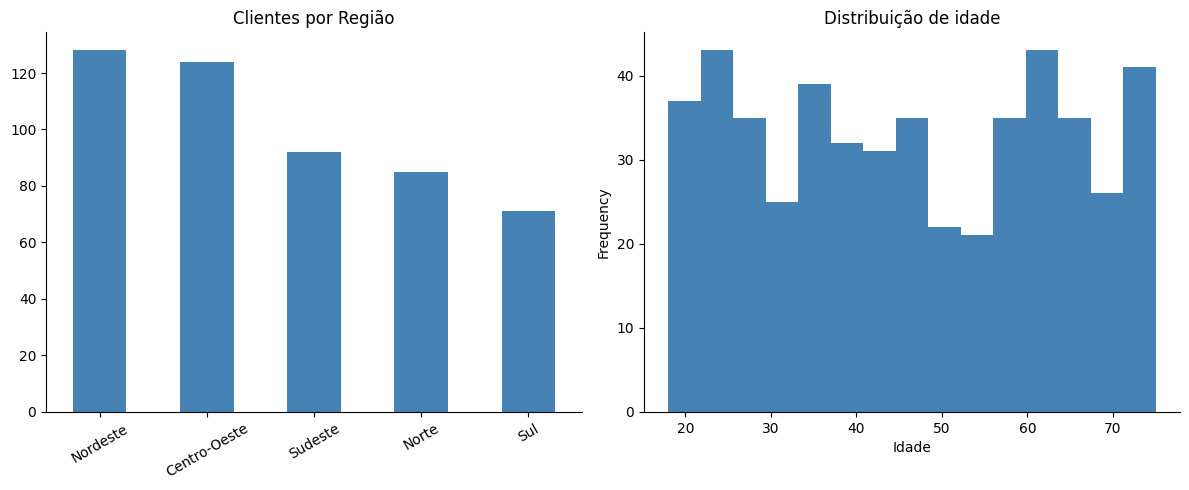

In [13]:
fig, axes = plt.subplots(1, 2)

#Clientes por região
clientes["regiao"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Clientes por Região")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

#Distribuição de idade
clientes["idade"].plot(kind="hist", ax=axes[1], color="steelblue", bins=15)
axes[1].set_title("Distribuição de idade")
axes[1].set_xlabel("Idade")

plt.tight_layout()
plt.show()

## Observações:
- Os clientes estão distribuídos de forma relativamente equilibrada entre as regiões, com leve concentração no Nordeste e Centro-Oeste
- A distribuição de idade é uniforme entre 18 e 75 anos, sem concentração em faixas etárias específicas — o que era esperado já que os dados foram gerados aleatoriamente

## 3. Análise de Pedidos

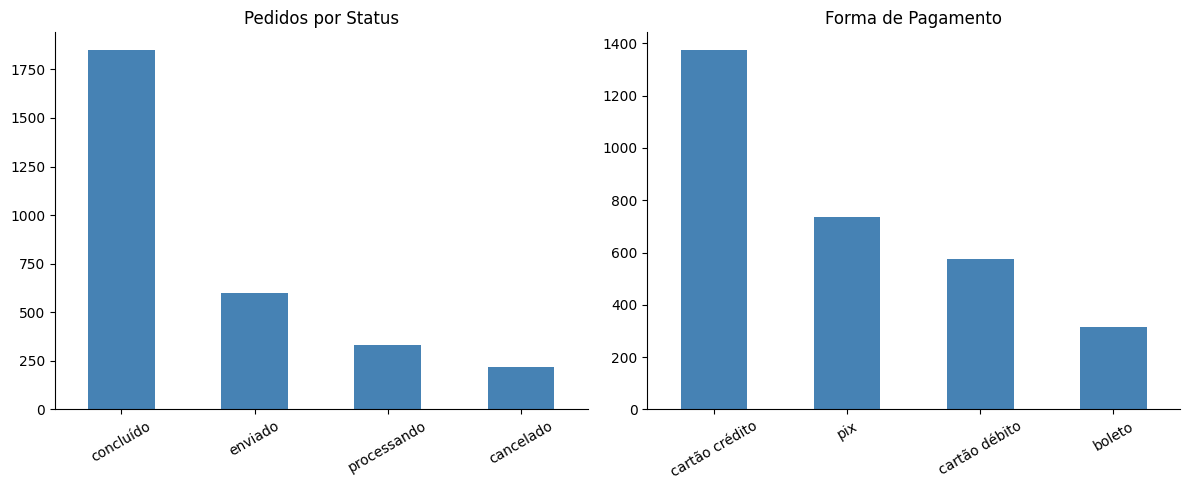

In [14]:
fig, axes = plt.subplots(1, 2)

# Status dos pedidos
pedidos["status"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Pedidos por Status")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Forma de pagamento
pedidos["forma_pagamento"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Forma de Pagamento")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Observações:
- 60% dos pedidos foram concluídos, confirmando o padrão definido na geração dos dados
- Cartão de crédito é a forma de pagamento dominante com ~45% dos pedidos, seguido de Pix com ~25% — refletindo o comportamento atual do e-commerce brasileiro

## 4. Análise de Produtos

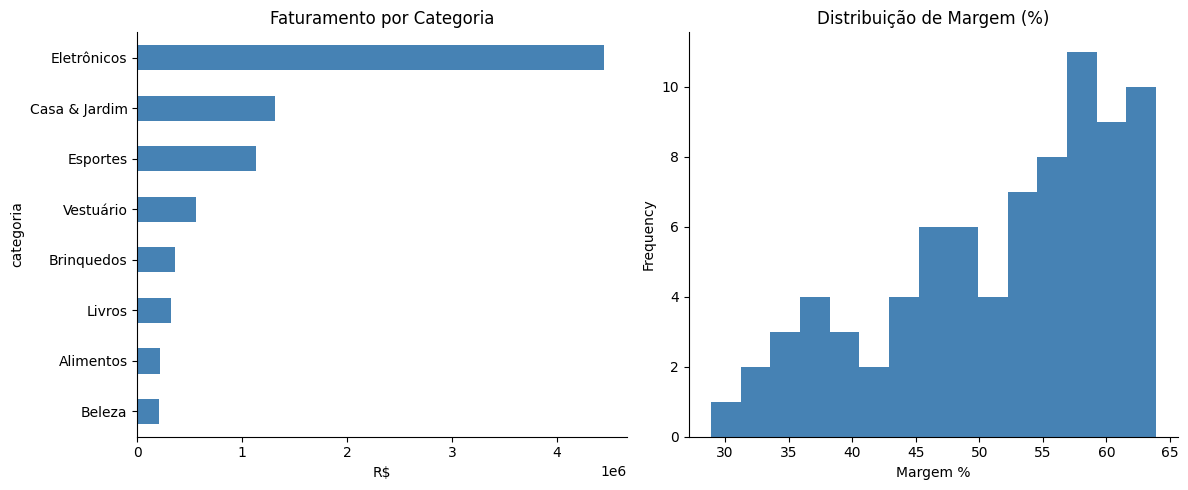

In [15]:
fig, axes = plt.subplots(1, 2)

# Faturamento por categoria
produtos_pedidos = itens.merge(produtos, on="produto_id")
fat_categoria = produtos_pedidos.groupby("categoria")["subtotal"].sum().sort_values()

fat_categoria.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Faturamento por Categoria")
axes[0].set_xlabel("R$")

# Distribuição de margem
produtos["margem_pct"].plot(kind="hist", ax=axes[1], color="steelblue", bins=15)
axes[1].set_title("Distribuição de Margem (%)")
axes[1].set_xlabel("Margem %")

plt.tight_layout()
plt.show()

## Observações:
- Eletrônicos domina o faturamento com folga — quase 4x mais que a segunda categoria (Casa & Jardim) — por ter os tickets mais altos
- A margem dos produtos se concentra entre 55%

## 5. Faturamento ao Longo do Tempo

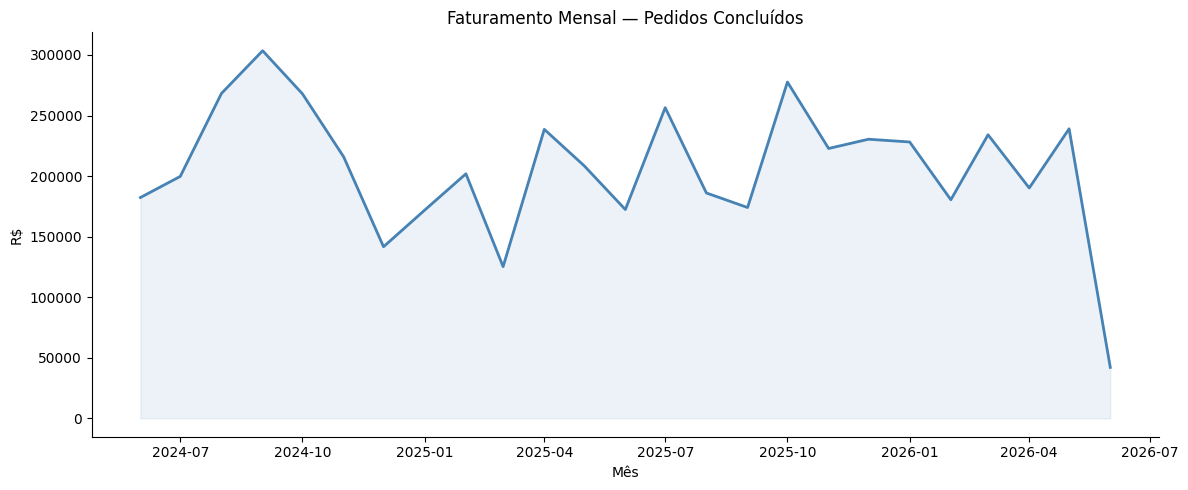

In [16]:
faturamento_mensal = pd.read_sql("SELECT * FROM vw_faturamento_mensal", conn)
faturamento_mensal["ano_mes"] = pd.to_datetime(faturamento_mensal["ano_mes"])

fig, ax = plt.subplots()

ax.plot(faturamento_mensal["ano_mes"], faturamento_mensal["faturamento"], color="steelblue", linewidth=2)
ax.fill_between(faturamento_mensal["ano_mes"], faturamento_mensal["faturamento"], alpha=0.1, color="steelblue")
ax.set_title("Faturamento Mensal — Pedidos Concluídos")
ax.set_xlabel("Mês")
ax.set_ylabel("R$")

plt.tight_layout()
plt.show()

## Observações:
- O faturamento se mantém estável entre R$ 150k e R$ 300k mensais ao longo dos 2 anos
- A queda em junho/2026 é esperada — o mês ainda estava em curso no momento da geração dos dados

## 6. Conclusão

A análise exploratória revelou que:
- Eletrônicos é a categoria mais lucrativa, respondendo pela maior parte do faturamento
- Cartão de crédito e Pix são as formas de pagamento preferidas dos clientes
- O faturamento mensal é estável, sem sazonalidade clara — o que é esperado em dados gerados aleatoriamente
- A base de clientes é demograficamente diversa, bem distribuída por região e faixa etária

Os dados estão prontos para análises mais aprofundadas e modelagem preditiva.